<a href="https://colab.research.google.com/github/Jaydenkaleb/Introduction-to-AI/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sunita Tebo

The insurance dataset contains information such as age, sex, BMI, number of children, smoking status, and residential region and charges, which represents the individual medical insurance cost.

In [1]:
#import the necessary library
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

In [2]:
#load teh dataset
df = pd.read_csv("insurance.csv")

Explore the dataset

In [3]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [4]:
print(df.tail())

      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603


In [5]:
print(df.shape)

(1338, 7)


In [6]:
#to check null values
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [7]:
print(df.describe)

<bound method NDFrame.describe of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>


In [8]:
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [9]:
#One-Hot encoding to the categorical columns such as sex, smoker, and region
df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

print(df_encoded.head())

   age     bmi  children  ...  region_northwest  region_southeast  region_southwest
0   19  27.900         0  ...             False             False              True
1   18  33.770         1  ...             False              True             False
2   28  33.000         3  ...             False              True             False
3   33  22.705         0  ...              True             False             False
4   32  28.880         0  ...              True             False             False

[5 rows x 9 columns]


In [10]:
#feature scaling to ensure unifomity of teh clustering process.
features = df_encoded.drop('charges', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(X_scaled.shape)

(1338, 8)


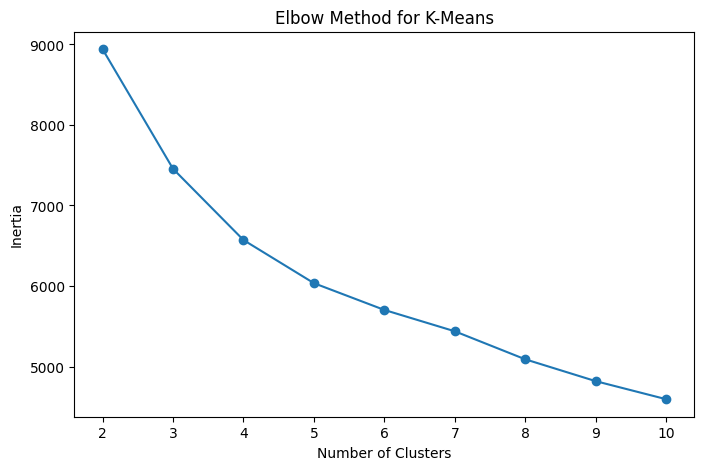

In [11]:
#Clustering using K-mean clustering
#determine the number of cluster using Elbow method.
#The elbow method runs k-means clustering on the dataset for a range of values of k (say 1 to 10)
#Then we Plot these points and find the point where the average distance from the centroid falls suddenly
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

Looking at teh curve, teh value of K is where the curve suddely decreases. therefore k= 4

In [12]:
#consider k= 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

df_encoded['KMeans_Cluster'] = kmeans_labels

print(df_encoded['KMeans_Cluster'].value_counts())

KMeans_Cluster
3    364
2    325
1    325
0    324
Name: count, dtype: int64


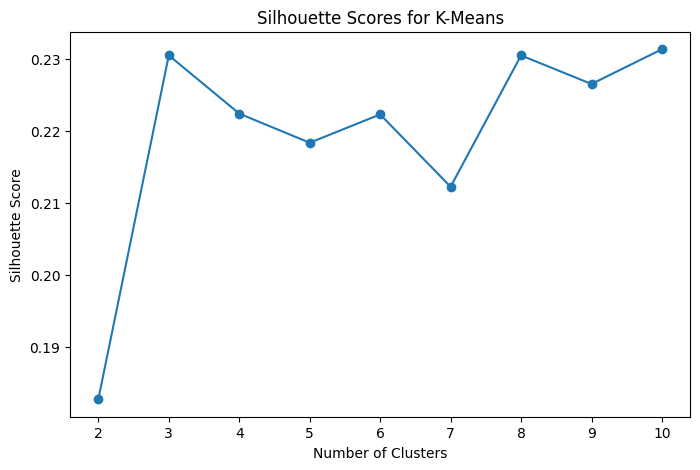

In [13]:
#using the silhouette score to determein K. ususally, the higher silhouette score indicates better-separated clusters.
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.show()

The highest silhouette score here is 0.23, implying K = 3, k= 8 and k=10

In [14]:
#when k= 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

df_encoded['KMeans_Cluster'] = kmeans_labels

print(df_encoded['KMeans_Cluster'].value_counts())

KMeans_Cluster
0    649
2    364
1    325
Name: count, dtype: int64


In [15]:
#when k = 8
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

df_encoded['KMeans_Cluster'] = kmeans_labels

print(df_encoded['KMeans_Cluster'].value_counts())

KMeans_Cluster
1    267
0    257
4    164
2    161
6    139
3    134
5    125
7     91
Name: count, dtype: int64


In [16]:
#when k = 10
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

df_encoded['KMeans_Cluster'] = kmeans_labels

print(df_encoded['KMeans_Cluster'].value_counts())

KMeans_Cluster
4    163
2    162
7    140
0    139
8    135
5    134
6    132
3    125
1    117
9     91
Name: count, dtype: int64


In [17]:
#Hierarchical Clustering> it does not require pre-specified number of clusters and it creates a hierarchy of clusters
hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df_encoded['Hierarchical_Cluster'] = hierarchical_labels

print(df_encoded['Hierarchical_Cluster'].value_counts())

Hierarchical_Cluster
0    797
2    274
1    267
Name: count, dtype: int64


In [18]:
#Calculate the silhouette score and K-Means

hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Clustering Silhouette Score:",
      hierarchical_score)

kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Silhouette Score:", kmeans_score)

Hierarchical Clustering Silhouette Score: 0.18706071358146786
K-Means Silhouette Score: 0.2313566222223781


Usually, the higher teh silhouette score (with a ranfe of 0-1) teh stronger the  separet clusters. however, looking at teh scores, it is a very low positive score, meaning the cluster created by the hierachical clsutering over laps considerably. meaning the data points are not clearly separated from each other cluster.

 Comparing it with the Kmean of 0.2314, it implies the Kmean, though still low, produces clusters that are a little separated from other clusters than the silhouette.

In [19]:
#mplement a dimensionality reduction technique (PCA, t-SNE) and visualize teh high dimensional data

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:",
      pca.explained_variance_ratio_)


Explained variance ratio: [0.19216849 0.16586792]


Note that Principal Componet analysis is a tool used for
data visualization or data pre-processing before
supervised techniques are applied. A variance of 0.1922 menasie abbout 19.22% variance is captured in teh original dataset and about 16.59% variance is captured.Together, the two components explain 35.81% of the total variance in the dataset.

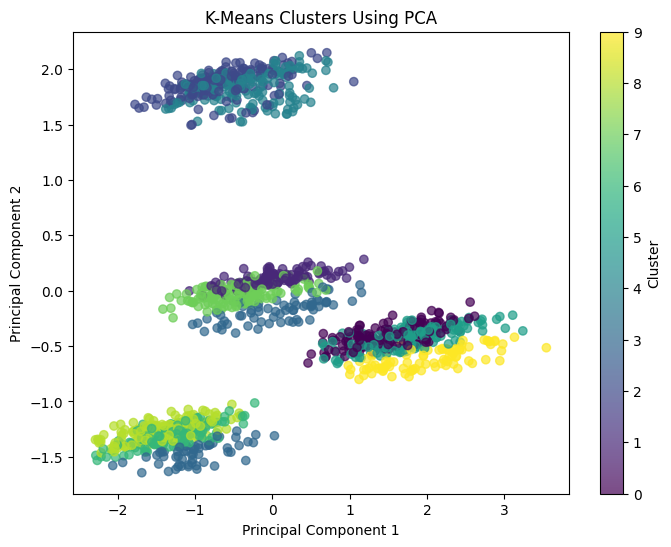

In [20]:
#visualize k-means
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Using PCA")
plt.colorbar(label="Cluster")

plt.show()

The PCA plot shows several groups of observations, indicating that K-Means identified distinct clusters. However, some overlap can be seen between the clusters. This is consistent with the K-Means Silhouette Score of 0.231, which indicates relatively weak cluster separation.

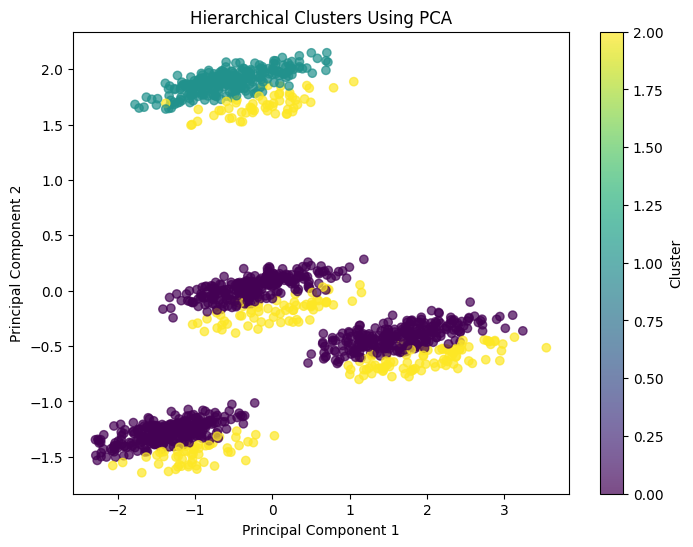

In [21]:
#Visualize hierachical clusteing
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clusters Using PCA")
plt.colorbar(label="Cluster")

plt.show()

The hierarchical plot has three major families of observations (teal, yellow and purple), even though each family contain several smaller subclusters

In [22]:
df_encoded.groupby('KMeans_Cluster').mean(numeric_only=True)

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,Hierarchical_Cluster
KMeans_Cluster,,,,,,,,,,
0,39.071942,32.780000,1.079137,8440.205552,0.000000,0.000000,0.000,1.0,0.0,0.000000
1,52.675214,31.496154,0.820513,12638.110999,0.444444,0.000000,0.000,0.0,0.0,0.000000
2,39.703704,30.060494,1.123457,11274.411264,0.000000,0.129630,0.000,0.0,1.0,1.129630
3,38.744000,28.832120,1.152000,29914.105026,0.536000,1.000000,0.464,0.0,0.0,2.000000
4,39.208589,31.129448,1.159509,13412.883576,1.000000,0.226994,0.000,0.0,1.0,1.226994
5,38.261194,34.129552,1.052239,7609.003587,1.000000,0.000000,0.000,1.0,0.0,0.000000
6,38.568182,28.930379,1.060606,8320.689321,1.000000,0.000000,1.000,0.0,0.0,0.000000
7,28.557143,27.523536,1.235714,6263.447519,0.521429,0.000000,0.000,0.0,0.0,0.000000
8,39.755556,29.488704,1.177778,8786.998679,0.000000,0.000000,1.000,0.0,0.0,0.000000


In [23]:
#Evaluating teh model
print("K-Means Silhouette Score:",
      kmeans_score)

print("Hierarchical Silhouette Score:",
      hierarchical_score)

K-Means Silhouette Score: 0.2313566222223781
Hierarchical Silhouette Score: 0.18706071358146786


The clustering models were evaluated using the Silhouette Score. The scores were used to determine how well the observations were separated into different clusters. A higher score indicates that observations within the same cluster are more similar and that the clusters are better separated.Overall. based on scores, none of the models were clearly separated from each other however, the K-Mean was better than the Hirachical.